# Introduction

**GitHub link:** https://github.com/cs418-fa25/project-check-in-team-15/blob/main/EDA.ipynb

In this project we work with economic features of communities in urban environment to try to predict unemployment and poverty indicators. For that goal we use U.S. Census Bureau's [American Community Survey (ACS)](https://www.census.gov/programs-surveys/acs/) data. This source was chosen for it's credibility, given it's an official government report, and vast amount of features recorded. We use few of them that are to be most likely predictors, but the number of attributes could be easily expanded if needed to. As for now, we use: year of the report, period of data gathering. unemployment rate, poverty rate, Bachelor's-plus rate, median household income, and average travel time.

The questions we are trying to investigate:
1. What are the predictors of poverty and unemployment rates?
2. What are geographic areas with high poverty and unemployment, and what do they have in common?
3. Measure gaps in economic outcomes across neighborhoods.

# Changes to the project


Since the last project check-in, we modified the scope to include other major urban areas besides Chicago, namely Dallas, New York, and Oklahoma City. We believe that this expansion will lead to a better general result and more robust analysis, especially considering the diversity of public policy approaches in them. Additionally, we modified our questions to reflect this change and to account for available data common to all regions.

# Data loading and cleaning

In [1]:
import pandas as pd # 2.3.3
import numpy as np # 2.3.4
import matplotlib.pyplot as plt # 3.10.7
import seaborn as sns # 0.13.2
from matplotlib.ticker import FuncFormatter

Loading the dataset into the notebook.

In [2]:
df = pd.read_csv('urban_economic_opportunity_data.csv')
df.head()

,GEOID,NAME,City,County_Name,ACS_Year,ACS_Period,Unemployment_Rate,Poverty_Rate,Bachelors_Plus_Rate,Median_Household_Income,Mean_Travel_Time_Minutes
0,17031010100,Census Tract 101; Cook County; Illinois,"Chicago, IL",Cook County,2023,2019-2023,0.0,14.01,46.13,69460.0,29.27
1,17031010201,Census Tract 102.01; Cook County; Illinois,"Chicago, IL",Cook County,2023,2019-2023,0.0,24.97,32.24,49639.0,54.45
2,17031010202,Census Tract 102.02; Cook County; Illinois,"Chicago, IL",Cook County,2023,2019-2023,0.0,22.90,49.95,55119.0,18.30
3,17031010300,Census Tract 103; Cook County; Illinois,"Chicago, IL",Cook County,2023,2019-2023,0.0,8.01,47.27,65871.0,48.37
4,17031010400,Census Tract 104; Cook County; Illinois,"Chicago, IL",Cook County,2023,2019-2023,0.0,16.16,63.60,49017.0,27.98


Removing negative household income.

It appears that some of the values are set to $-666666666.66, which could have been used as a placeholder data.

In [3]:
df = df[df['Median_Household_Income'] >= 0]
df.describe()

,GEOID,ACS_Year,Unemployment_Rate,Poverty_Rate,Bachelors_Plus_Rate,Median_Household_Income,Mean_Travel_Time_Minutes
count,4.407000e+03,4407.0,4407.000000,4407.000000,4407.000000,4407.000000,4407.000000
mean,3.236208e+10,2023.0,0.206088,15.555149,38.600520,86362.184025,26.100445
std,1.080154e+10,0.0,2.718635,11.451099,23.102622,42819.667139,13.107398
min,1.703101e+10,2023.0,0.000000,0.000000,0.270000,6311.000000,0.030000
25%,1.703182e+10,2023.0,0.000000,6.890000,20.295000,57324.500000,16.480000
50%,3.604707e+10,2023.0,0.000000,12.550000,33.850000,78187.000000,24.170000
75%,3.608111e+10,2023.0,0.000000,21.280000,53.045000,105062.500000,33.640000
max,4.811398e+10,2023.0,135.530000,76.990000,100.000000,250001.000000,106.930000


Removing any rates > 100.

Since there is no case where more than 100% of population belongs in either category.

In [4]:
df = df[(df['Unemployment_Rate'] <= 100) & (df['Poverty_Rate'] <= 100) & (df['Bachelors_Plus_Rate'] <= 100)]
df.describe()

,GEOID,ACS_Year,Unemployment_Rate,Poverty_Rate,Bachelors_Plus_Rate,Median_Household_Income,Mean_Travel_Time_Minutes
count,4.406000e+03,4406.0,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000
mean,3.236124e+10,2023.0,0.175374,15.558679,38.598566,86353.029732,26.105502
std,1.080262e+10,0.0,1.798468,11.450000,23.104880,42820.214101,13.104586
min,1.703101e+10,2023.0,0.000000,0.000000,0.270000,6311.000000,0.030000
25%,1.703182e+10,2023.0,0.000000,6.892500,20.292500,57317.750000,16.485000
50%,3.604707e+10,2023.0,0.000000,12.555000,33.840000,78185.500000,24.175000
75%,3.608111e+10,2023.0,0.000000,21.280000,53.047500,105034.750000,33.645000
max,4.811398e+10,2023.0,86.760000,76.990000,100.000000,250001.000000,106.930000


# Exploratory data analysis

We start the EDA from a statistical analysis of numeric features.


In [5]:
df.describe()

,GEOID,ACS_Year,Unemployment_Rate,Poverty_Rate,Bachelors_Plus_Rate,Median_Household_Income,Mean_Travel_Time_Minutes
count,4.406000e+03,4406.0,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000
mean,3.236124e+10,2023.0,0.175374,15.558679,38.598566,86353.029732,26.105502
std,1.080262e+10,0.0,1.798468,11.450000,23.104880,42820.214101,13.104586
min,1.703101e+10,2023.0,0.000000,0.000000,0.270000,6311.000000,0.030000
25%,1.703182e+10,2023.0,0.000000,6.892500,20.292500,57317.750000,16.485000
50%,3.604707e+10,2023.0,0.000000,12.555000,33.840000,78185.500000,24.175000
75%,3.608111e+10,2023.0,0.000000,21.280000,53.047500,105034.750000,33.645000
max,4.811398e+10,2023.0,86.760000,76.990000,100.000000,250001.000000,106.930000


Investigating relationship between education level ("Bachelors Plus Rate") and income ("Median Household Income") in each city.

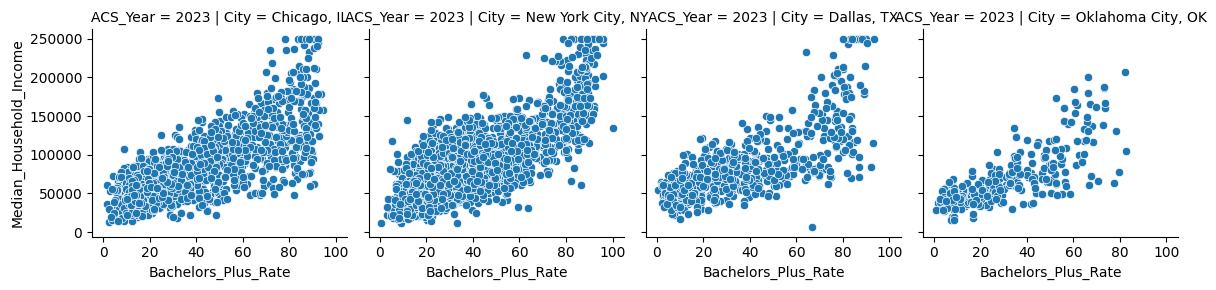

In [6]:
#fig, ax = plt.subplots()
grid = sns.FacetGrid(data=df, col='City', row='ACS_Year')
grid.map(sns.scatterplot, 'Bachelors_Plus_Rate', 'Median_Household_Income')
grid
#plt.show()

Investigating average "median household income" in every city.

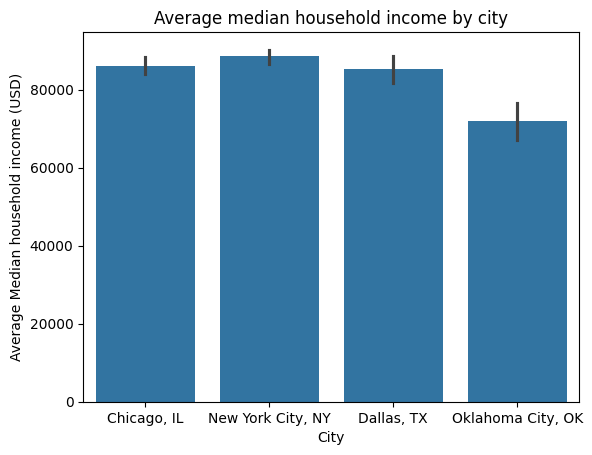

In [7]:
# this is just an example visualization od a boring question
fig, ax = plt.subplots()
sns.barplot(ax = ax, data=df, x='City', y='Median_Household_Income', estimator=np.mean)
ax.set_title("Average median household income by city")
ax.set_xlabel("City")
ax.set_ylabel("Average Median household income (USD)")

plt.show()

Investigating Overall distribution of income ("median household income") and distribution per-city.

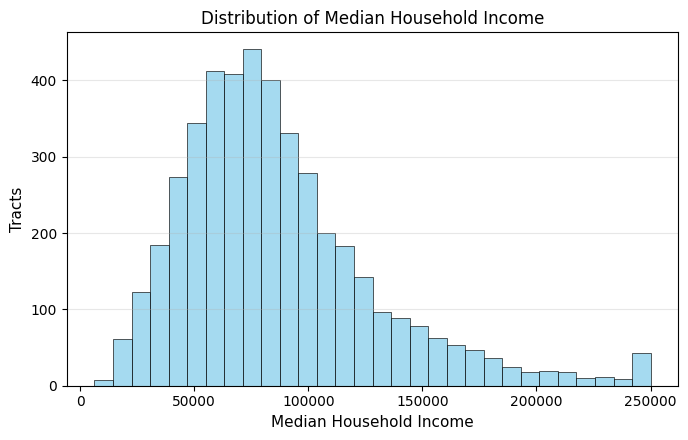

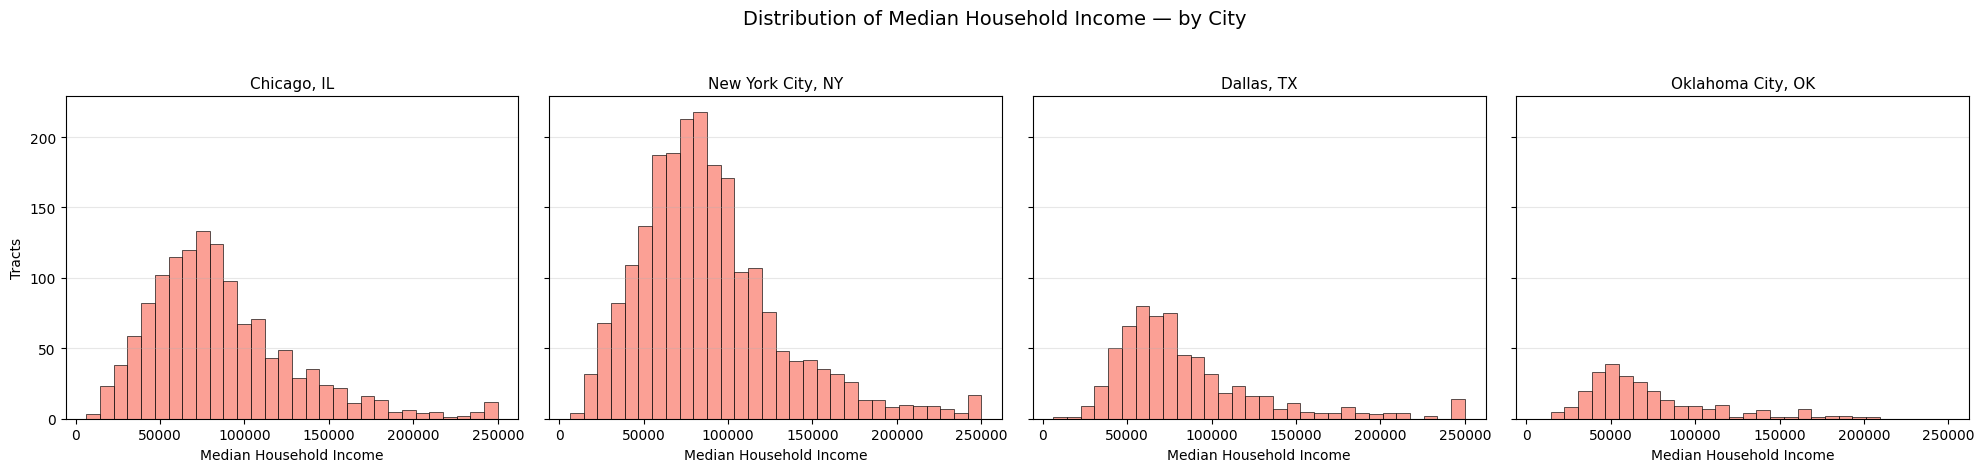

In [8]:
x = df["Median_Household_Income"].dropna().values

plt.figure(figsize=(7, 4.5))
plt.hist(
    x, bins=30,
    edgecolor="black", linewidth=0.6,
    alpha=0.75, color="skyblue"
)
plt.title("Distribution of Median Household Income", fontsize=12)
plt.xlabel("Median Household Income", fontsize=11)
plt.ylabel("Tracts", fontsize=11)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


bin_edges = np.histogram_bin_edges(df["Median_Household_Income"].dropna().values, bins=30)
cities = ["Chicago, IL", "New York City, NY", "Dallas, TX", "Oklahoma City, OK"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)

for ax, city in zip(axes, cities):
    
    x_city = pd.to_numeric(
        df.loc[df["City"] == city, "Median_Household_Income"],
        errors="coerce"
    ).dropna().values

    ax.hist(
        x_city, bins=bin_edges,
        edgecolor="black", linewidth=0.6,
        alpha=0.75, color="salmon"
    )
    
    ax.set_title(city, pad=6, fontsize=11)
    ax.set_xlabel("Median Household Income", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Tracts", fontsize=10)

fig.suptitle("Distribution of Median Household Income — by City", fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

Investigating the comparative distribution of "Bachelor Plus Rate" in each city.

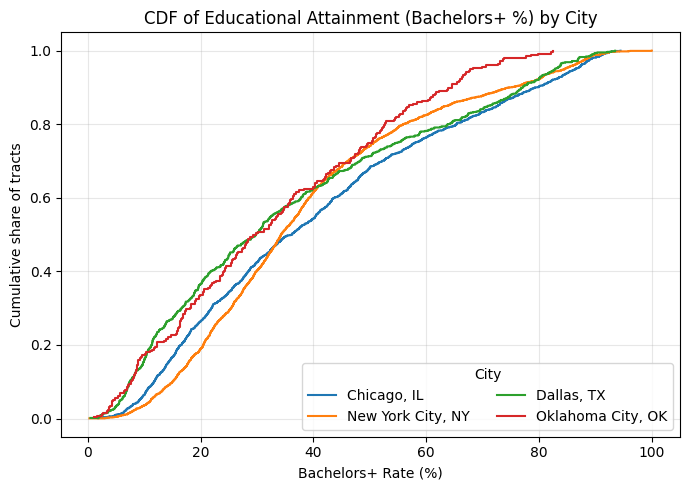

In [9]:
plt.figure(figsize=(7,5))

Cities = ["Chicago, IL", "New York City, NY", "Dallas, TX", "Oklahoma City, OK"]

for city in Cities:
    
    vals = np.sort(df.loc[df["City"] == city, "Bachelors_Plus_Rate"].dropna().values)
    
    cdf = np.arange(1, len(vals)+1) / len(vals)
    
    plt.plot(vals, cdf, drawstyle="steps-post", label=city)

plt.xlabel("Bachelors+ Rate (%)")
plt.ylabel("Cumulative share of tracts")
plt.title("CDF of Educational Attainment (Bachelors+ %) by City")
plt.legend(title="City", ncols=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Investigating poverty and travel time relationship.


/home/dm/miniconda3/envs/CS418/lib/python3.11/site-packages/seaborn/distributions.py:2125: UserWarning: `displot` is a figure-level function and does not accept the ax= parameter. You may wish to try histplot.
  warnings.warn(msg, UserWarning)


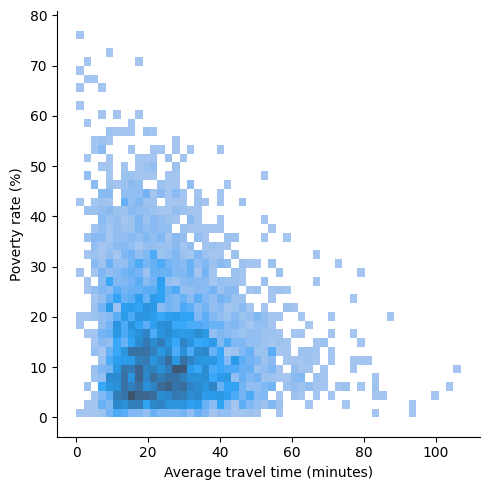

In [10]:
plot = sns.displot(ax=ax, data=df, x='Mean_Travel_Time_Minutes', y='Poverty_Rate')
plot.set_xlabels("Average travel time (minutes)")
plot.set_ylabels("Poverty rate (%)")
plt.show()

Looking at distribution of travel time in all cities.

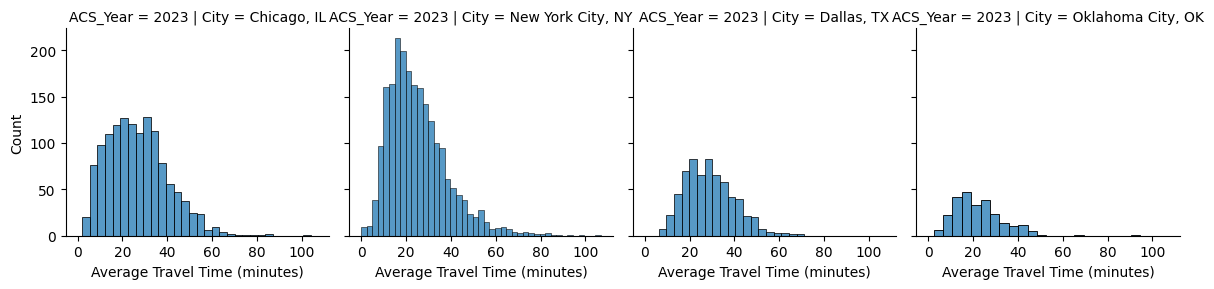

In [11]:
grid = sns.FacetGrid(data=df, col='City', row='ACS_Year')
grid.map(sns.histplot, 'Mean_Travel_Time_Minutes')
grid.set_xlabels("Average Travel Time (minutes)")

# Interesting visualizations

## Hypothesis 1: Distribution of poverty rate across income is not uniform.

To verify hypothesis, we needed to map the "Poverty rate" to the "Median Median Household Income" feature. Additionally, we needed a third dimension that would indicate density of occurrences of a certain binned poverty rate in a income bracket. To account for all of that, including automatic binning, heatmap was the optimal choice.

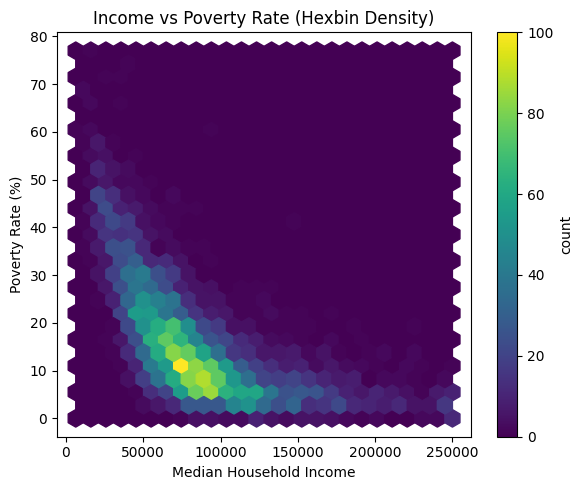

In [12]:
income = df["Median_Household_Income"]
y = df["Poverty_Rate"]

plt.figure(figsize=(6,5))
hb = plt.hexbin(income, y, gridsize=25)
plt.colorbar(hb, label="count")
plt.xlabel("Median Household Income")
plt.ylabel("Poverty Rate (%)")
plt.title("Income vs Poverty Rate (Hexbin Density)")
plt.tight_layout()
plt.show()

From the visualizations you can see that our hypothesis was correct, in lower income areas (<$50,000) the poverty rate seems to have high degree of variance, inversely proportional to median income itself. In higher income areas (>$50,000) the poverty rate seemed to be more uniform, with lover variance as median income increases. Additionally, we identified that the ratio of two variables are not equally distributed either, with the most common occurrence being at approximately 10% poverty rate and $75,000 median income. With much rare cases at extremes.

## Hypothesis 2: "Blue" and "Red" cities have different education-to-income ratio.

To verify the hypothesis, we need to compare "Bachelors Plus Rate" to "Median Household Income." This is just two variables, but we would also need to add the third one - groups. We group Chicago and New York into "Blue" group, and Dallas and Oklahoma City into "Red" group. Since we need to compare trends in each group, linechart would work perfectly.

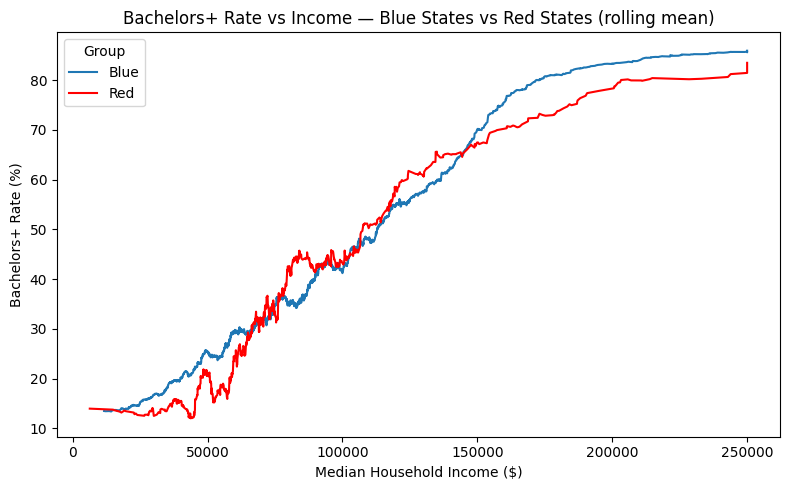

In [13]:
blue_cities = {"Chicago, IL", "New York City, NY"}
red_cities  = {"Dallas, TX", "Oklahoma City, OK"}

cols = ["Median_Household_Income", "Bachelors_Plus_Rate", "City"]

df_lr = df.dropna(subset=cols).copy()

#df_lr["Group"] = np.where(df_lr["City"].astype(str).isin(blue_cities), "Blue", np.where(df_lr["City"].astype(str).isin(red_cities), "Red", np.nan))

df_lr.loc[(df_lr["City"].isin(blue_cities)), "Group"] = "Blue"
df_lr.loc[(df_lr["City"].isin(red_cities)), "Group"] = "Red"

df_lr = df_lr.dropna(subset=["Group"])

def rolling_xy(x, y, window):
    order = np.argsort(x)
    
    xs = x[order]
    ys = y[order]
        
    peroids = window // 3
    temp = pd.Series(ys).rolling(window=window, center=True, min_periods=peroids)
    
    s = temp.mean().values
    return xs, s

plt.figure(figsize=(8,5))
for g in ["Blue", "Red"]:
    
    plot_cols = ["Median_Household_Income", "Bachelors_Plus_Rate", "Group"]
    sub = df_lr.loc[df_lr["Group"] == g, plot_cols].dropna()

    income_data = sub["Median_Household_Income"].values
    education = sub["Bachelors_Plus_Rate"].values
    
    win = int(len(sub) * 0.05)
    xs, ys = rolling_xy(income_data, education, window=win)
    
    colors = {"Blue": "tab:blue", "Red": "red"}
    plt.plot(xs, ys, marker="", label=g, color=colors[g])


plt.xlabel("Median Household Income ($)")
plt.ylabel("Bachelors+ Rate (%)")
plt.title("Bachelors+ Rate vs Income — Blue States vs Red States (rolling mean)")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

From the visualizations you can see that, while there are some differences on certain income levels (particularly around $80,000), generally, both of the groups follow the same trend, disproving our hypothesis. Additionally to that, we identified some interesting intervals in Median Household Income. Firstly, on lover end there are few "jumps" in Bachelors rate, more profound in "Red" cities. Secondly, at the higher end of the income, blue states have consistently higher Bachelors rates, which could be investigated.

# Prediction component


For our first prediction task, we decided to use **Unemployment Rate** as the dependent variable. We picked this because unemployment is one of the clearest ways to measure how well a community is doing economically. It also depends on a lot of different social and structural factors, which makes it interesting to model.  

The independent variables we plan to use are:  

- **Median Household Income** – usually higher incomes go along with lower unemployment, so it makes sense as a predictor.  
- **Bachelors+ Rate** – education is a big factor in employability, and areas with more people holding college degrees should have lower unemployment.  
- **Mean Travel Time (minutes)** – this gives some sense of how easy it is for people to reach jobs; longer commutes could mean fewer local job opportunities.  
- **ACS Year / Period** – the economy changes year to year, so including time can help capture things like recessions or recoveries.  
- **City** – since each city has its own policies and economy, we want to include city as a categorical feature to capture regional differences.  

Overall, this mix of variables covers socioeconomic (income, education), infrastructure (commute times), and location-based (city, year) factors. We think this makes the model more balanced and realistic. Later on, we also plan to try predicting **Poverty Rate** to see how the results compare.  


# Reflection

- Biggest obstacles on this step were data acquisition and organization, both of which we dealt with.
- Initial insights mostly concentrate on relationships between specific values, more specifically, distribution of income across cities, that education-income has a near-universal relation, and comparing of such between "Red" and "Blue" states.
- Only concrete results, so far, has been derived from exploration of the data. Namely, the similarity of variables distribution across cities, proving generality of the data and possibility of applying resulting model in other places too. Model itself is dedicated to future work.
- So far, the hardest part of the project is formulation and coordination. While goals are clear, the steps to get to them aren't so. With most of tasks being intertwined and dependent from one-another, some planning needs to be done before proceeding.
- The overall progress on the project is steady, and we up-to-date with tasks.
- According to our findings so far, it is completely possible to build a model with what we have right now, which means the project is worth completing.

# Team roles

Our main coordination is happening on dedicated Discord server, with the GitHub repository being storage/collaboration space for code and results. Responsobilities has been divided as such:

**Data & Preparation**
- Muhammad Taha (mtaha6@uic.edu)

**Statistical data analysis**
- Bhavisha Ahuja (bahuja2@uic.edu)

**Visual data analysis**
- Filip Petrev (fpetr2@uic.edu)

**Prediction and modeling**
- Sai Rohit Mahadas (smaha23@uic.edu)

**Coordination & Documentation**
- Dima Medvedkov (dmedve2@uic.edu)


Those roles are not hard requirements and all team members may help with one or other component of the project.

# Next steps

For the next steps we would need to consider next directions:
- For more in-depth data analysis we need to identify unobvious relationships between features we have right now and any added in the future.
    1. Investigate up-to-date domain knowledge on correlations.
    2. Look into non-linear correlations within current data.
- For feature prediction, we need to run an an analysis on features (that is partially would be done in previous point).
    1. Add/remove features based on previous analysis, i.e. remove insignificant features and add pot`entirely promising ones.
    2. Run correlation analysis to filter-out unnecessary features and identify the most important ones.
    3. Choose a list of models and train them on the data.


To evaluate success of the previous steps the following results are expected:
1. List of relationships between attributes.
2. Model that predicts target variables within 95% percent accuracy across the test data.